# Telco Customer Churn Prediction

### Business Problem

Customer churn is a major challenge for telecom companies. The objective of this project is to predict whether a customer is likely to leave the company using machine learning techniques.

### Project Objectives

- Analyze customer behavior
- Identify churn drivers
- Compare multiple ML models
- Select the best-performing model
- Explain predictions using SHAP

### Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import os
os.makedirs('plots', exist_ok=True)
import joblib

In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [4]:
print("Shape:", df.shape)         
print("Churn values:", df['Churn'].unique())  

Shape: (7043, 21)
Churn values: ['No' 'Yes']


## Exploratory Data Analysis (EDA)

Understanding customer demographics, contracts, tenure, charges, and churn distribution.

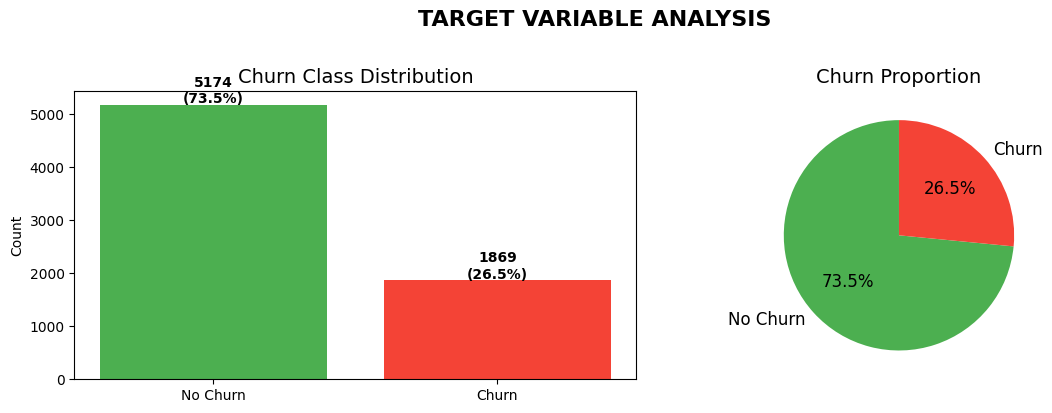

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df['Churn'].value_counts()
axes[0].bar(['No Churn', 'Churn'], counts.values, color=['#4CAF50', '#F44336'])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Churn Class Distribution', fontsize=14)
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(counts.values, labels=['No Churn', 'Churn'],
            colors=['#4CAF50', '#F44336'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Churn Proportion', fontsize=14)

plt.suptitle('TARGET VARIABLE ANALYSIS', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_17864\2059274943.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1].set_xticklabels(churn_rate.index, rotation=15)


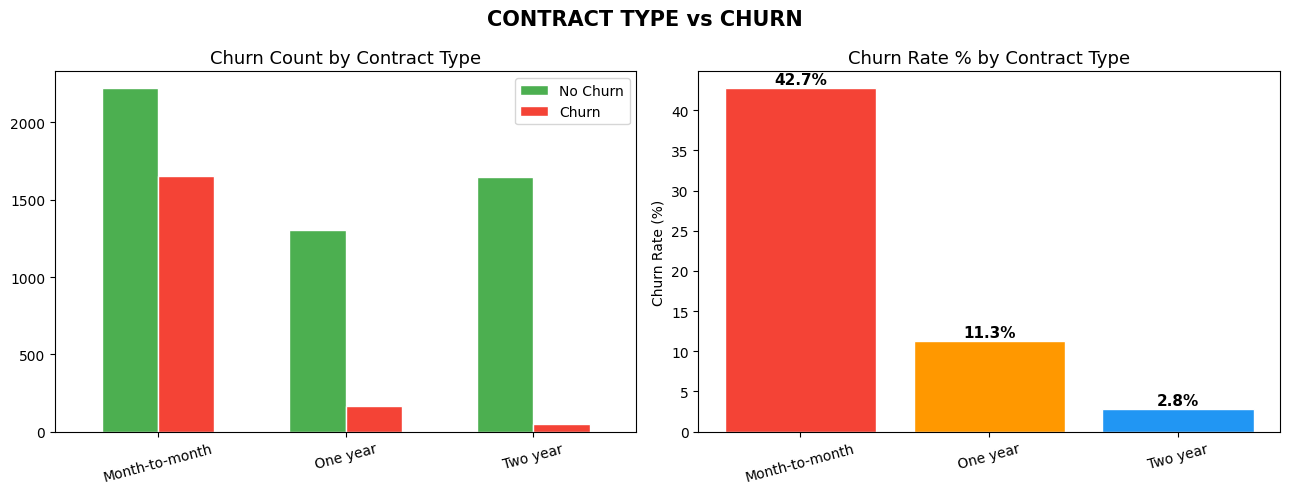

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Stacked bar — counts
contract_churn = df.groupby(['Contract', 'Churn']).size().unstack()
contract_churn.plot(kind='bar', ax=axes[0], color=['#4CAF50', '#F44336'],
                    edgecolor='white', width=0.6)
axes[0].set_title('Churn Count by Contract Type', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)
axes[0].legend(['No Churn', 'Churn'])

# Churn rate %
churn_rate = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
)
bars = axes[1].bar(churn_rate.index, churn_rate.values,
                   color=['#F44336', '#FF9800', '#2196F3'], edgecolor='white')
for bar, val in zip(bars, churn_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Churn Rate % by Contract Type', fontsize=13)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticklabels(churn_rate.index, rotation=15)

plt.suptitle('CONTRACT TYPE vs CHURN', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/02_contract_churn.png', dpi=150, bbox_inches='tight')
plt.show()

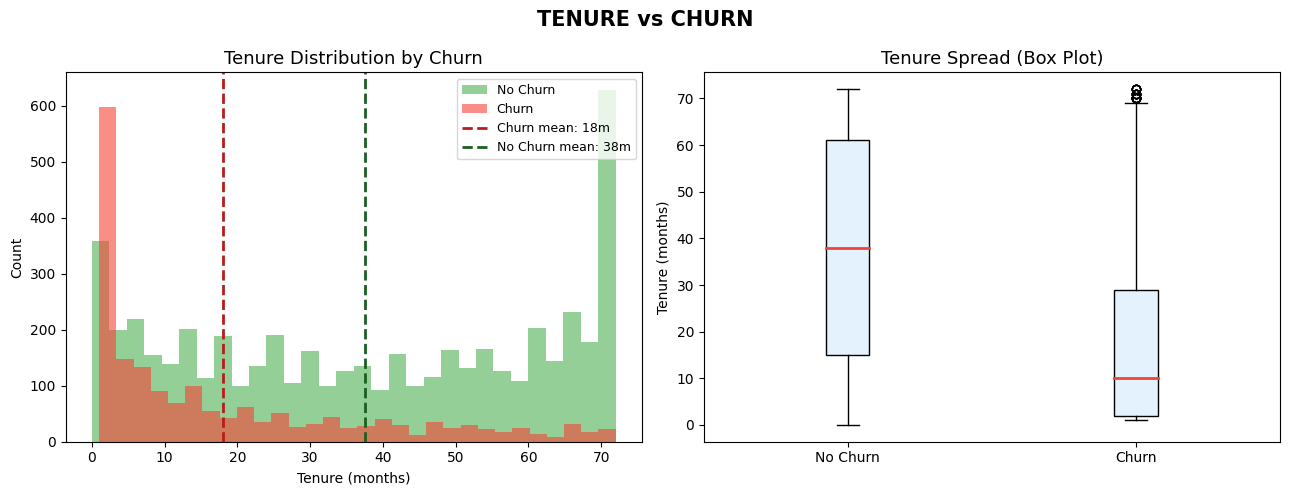

Avg tenure - Churned:     18.0 months
Avg tenure - Not Churned: 37.6 months


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

churned    = df[df['Churn'] == 'Yes']['tenure']
not_churned = df[df['Churn'] == 'No']['tenure']

# Overlapping histogram
axes[0].hist(not_churned, bins=30, alpha=0.6, color='#4CAF50', label='No Churn')
axes[0].hist(churned,     bins=30, alpha=0.6, color='#F44336', label='Churn')
axes[0].set_title('Tenure Distribution by Churn', fontsize=13)
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Add mean lines
axes[0].axvline(churned.mean(),     color='#B71C1C', linestyle='--', linewidth=2,
                label=f'Churn mean: {churned.mean():.0f}m')
axes[0].axvline(not_churned.mean(), color='#1B5E20', linestyle='--', linewidth=2,
                label=f'No Churn mean: {not_churned.mean():.0f}m')
axes[0].legend(fontsize=9)

# Box plot
df_plot = df[['tenure', 'Churn']].copy()
churned_box    = df_plot[df_plot['Churn'] == 'Yes']['tenure']
not_churned_box = df_plot[df_plot['Churn'] == 'No']['tenure']
axes[1].boxplot([not_churned_box, churned_box], labels=['No Churn', 'Churn'],
                patch_artist=True,
                boxprops=dict(facecolor='#E3F2FD'),
                medianprops=dict(color='#F44336', linewidth=2))
axes[1].set_title('Tenure Spread (Box Plot)', fontsize=13)
axes[1].set_ylabel('Tenure (months)')

plt.suptitle('TENURE vs CHURN', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/03_tenure_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Avg tenure - Churned:     {churned.mean():.1f} months")
print(f"Avg tenure - Not Churned: {not_churned.mean():.1f} months")

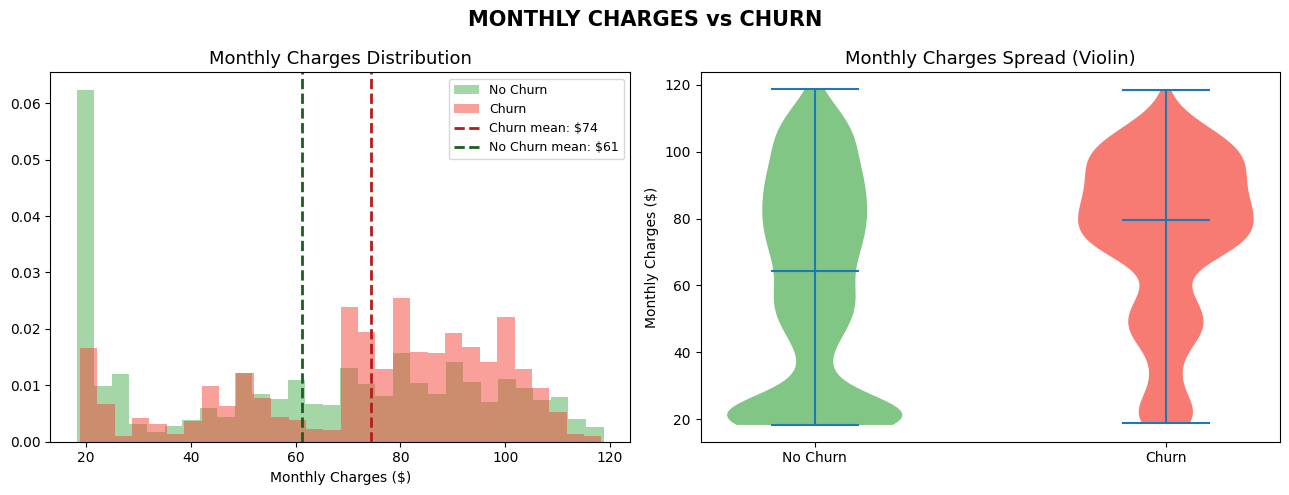

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

churned_mc    = df[df['Churn'] == 'Yes']['MonthlyCharges']
not_churned_mc = df[df['Churn'] == 'No']['MonthlyCharges']

# KDE plot — smoother than histogram for continuous data
axes[0].hist(not_churned_mc, bins=30, alpha=0.5, color='#4CAF50',
             label='No Churn', density=True)
axes[0].hist(churned_mc,     bins=30, alpha=0.5, color='#F44336',
             label='Churn',    density=True)
axes[0].axvline(churned_mc.mean(),     color='#B71C1C', linestyle='--',
                linewidth=2, label=f'Churn mean: ${churned_mc.mean():.0f}')
axes[0].axvline(not_churned_mc.mean(), color='#1B5E20', linestyle='--',
                linewidth=2, label=f'No Churn mean: ${not_churned_mc.mean():.0f}')
axes[0].set_title('Monthly Charges Distribution', fontsize=13)
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].legend(fontsize=9)

# Violin plot — shows distribution shape beautifully
import numpy as np
data_to_plot = [not_churned_mc.values, churned_mc.values]
parts = axes[1].violinplot(data_to_plot, positions=[1, 2], showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(['#4CAF50', '#F44336'][i])
    pc.set_alpha(0.7)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['No Churn', 'Churn'])
axes[1].set_title('Monthly Charges Spread (Violin)', fontsize=13)
axes[1].set_ylabel('Monthly Charges ($)')

plt.suptitle('MONTHLY CHARGES vs CHURN', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/04_monthlycharges_churn.png', dpi=150, bbox_inches='tight')
plt.show()

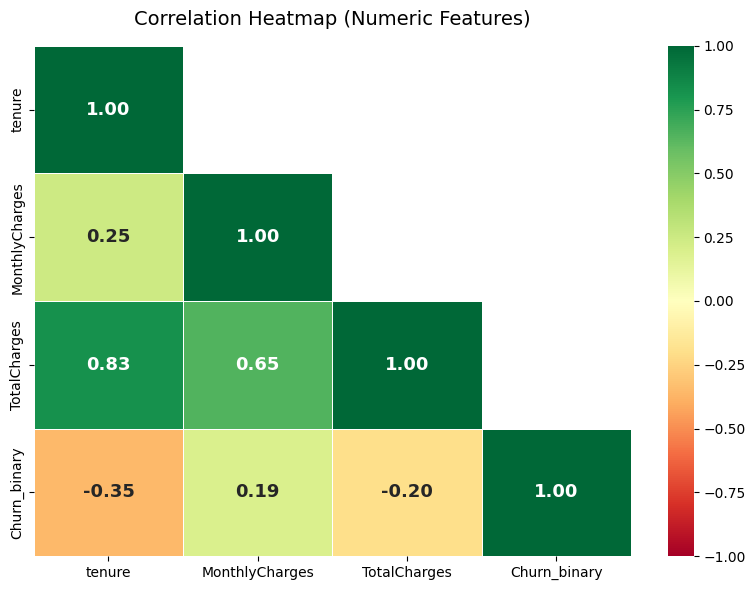

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

# Only numeric columns
numeric_cols = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
numeric_cols['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

corr = numeric_cols.corr()

mask = pd.DataFrame(False, index=corr.index, columns=corr.columns)
# mask upper triangle
import numpy as np
mask.values[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, mask=mask,
            annot_kws={"size": 13, "weight": "bold"})
ax.set_title('Correlation Heatmap (Numeric Features)', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('plots/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

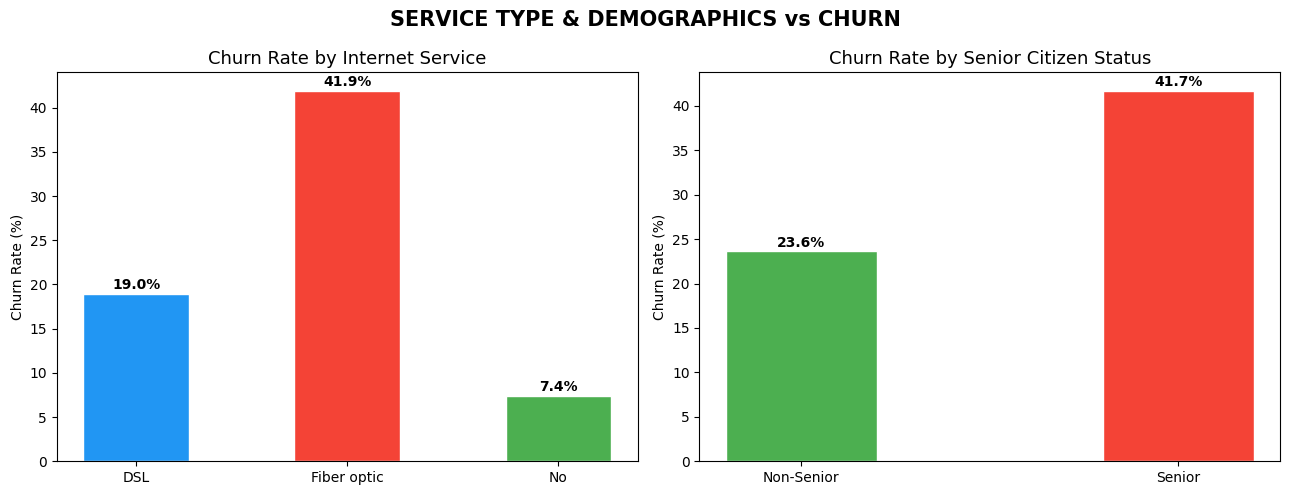

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Internet service churn rate
internet_rate = df.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
)
colors = ['#2196F3', '#F44336', '#4CAF50']
bars = axes[0].bar(internet_rate.index, internet_rate.values,
                   color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, internet_rate.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Churn Rate by Internet Service', fontsize=13)
axes[0].set_ylabel('Churn Rate (%)')

# Senior citizen churn rate
senior_rate = df.groupby('SeniorCitizen')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
)
axes[1].bar(['Non-Senior', 'Senior'], senior_rate.values,
            color=['#4CAF50', '#F44336'], edgecolor='white', width=0.4)
for i, val in enumerate(senior_rate.values):
    axes[1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Churn Rate by Senior Citizen Status', fontsize=13)
axes[1].set_ylabel('Churn Rate (%)')

plt.suptitle('SERVICE TYPE & DEMOGRAPHICS vs CHURN', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/06_service_senior_churn.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations

- Month-to-month customers show higher churn.
- Customers with fiber internet churn more frequently.
- Higher monthly charges correlate with churn.
- Long-tenure customers are less likely to churn.

## Data Preprocessing

Preparing the dataset for machine learning:
- Remove irrelevant columns
- Handle target encoding
- One-hot encoding
- Feature preparation

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [50]:
df_model = df.copy()

In [51]:
df_model.drop('customerID', axis=1, inplace=True)

In [52]:
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

In [53]:
df_model = pd.get_dummies(df_model, drop_first=True)

In [54]:
print("Shape after encoding:", df_model.shape)
print("Columns:", df_model.shape[1])

Shape after encoding: (7043, 31)
Columns: 31


In [55]:
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

## Train-Test Split

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

## Class Imbalance Handling Using SMOTE

In [57]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_res).value_counts().to_dict())


Before SMOTE: {0: 4139, 1: 1495}
After SMOTE:  {0: 4139, 1: 4139}


In [58]:
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print("\ Preprocessing complete!")
print("X_train_res shape:", X_train_res.shape)   
print("X_test_scaled shape:", X_test_scaled.shape) 

\ Preprocessing complete!
X_train_res shape: (8278, 30)
X_test_scaled shape: (1409, 30)


## Model Development and Comparison

Three models are evaluated using 5-fold cross-validation:

- XGBoost
- LightGBM
- Random Forest

Evaluation Metric:
- ROC-AUC

In [59]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (roc_auc_score, f1_score, 
                              classification_report, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

# --- Define 3 models ---
models = {
    'XGBoost'      : XGBClassifier(use_label_encoder=False, 
                                    eval_metric='logloss', random_state=42),
    'LightGBM'     : LGBMClassifier(random_state=42, verbose=-1),
    'RandomForest' : RandomForestClassifier(class_weight='balanced', 
                                             random_state=42)
}

# --- Cross validation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 50)
print("     MODEL COMPARISON (5-Fold Cross Validation)")
print("=" * 50)

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_res, y_train_res,   #  fixed order
                             cv=cv, scoring='roc_auc')
    results[name] = scores.mean()
    print(f"{name:15} → AUC: {scores.mean():.4f} ± {scores.std():.4f}")

best_model_name = max(results, key=results.get)
print(f"\n🏆 Best model: {best_model_name} (AUC: {results[best_model_name]:.4f})")

     MODEL COMPARISON (5-Fold Cross Validation)
XGBoost         → AUC: 0.9301 ± 0.0044
LightGBM        → AUC: 0.9306 ± 0.0055
RandomForest    → AUC: 0.9288 ± 0.0057

🏆 Best model: LightGBM (AUC: 0.9306)


## Final Model Evaluation

In [60]:
best_model = models[best_model_name]
best_model.fit(X_train_res, y_train_res)

y_pred      = best_model.predict(X_test_scaled)
y_pred_prob = best_model.predict_proba(X_test_scaled)[:, 1]

print("TEST SET RESULTS")
print("=" * 50)
print(f"AUC-ROC Score : {roc_auc_score(y_test, y_pred_prob):.4f}")
print(f"F1 Score      : {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

TEST SET RESULTS
AUC-ROC Score : 0.8264
F1 Score      : 0.5899

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.86      0.82      0.84      1035
       Churn       0.56      0.62      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.72      1409
weighted avg       0.78      0.77      0.77      1409



### Confusion Matrix Plot 

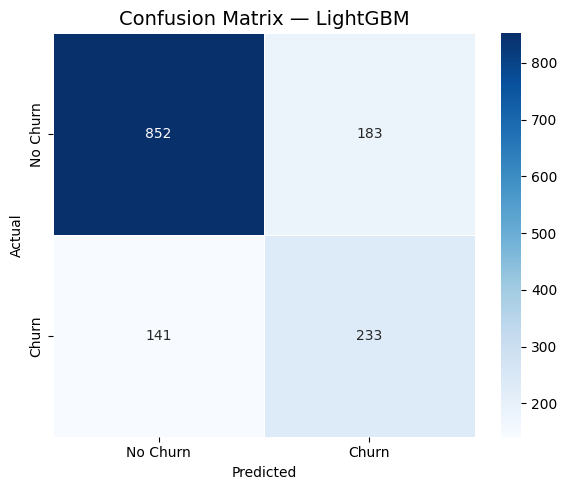

In [62]:

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            linewidths=0.5, ax=ax)
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=14)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('plots/07_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Model Explainability Using SHAP

## Model Persistence

In [63]:
# ============================================
# FIXED PREPROCESSING + TRAINING — FULL CLEAN
# ============================================
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline  # ✅ KEY FIX — use imblearn Pipeline
import warnings
warnings.filterwarnings('ignore')

# --- Fresh split from df_model ---
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ✅ CORRECT WAY — SMOTE inside pipeline, applied ONLY to training folds
# This prevents any synthetic data from leaking into test set
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model', LGBMClassifier(random_state=42, verbose=-1))
])

# --- Cross validation on ORIGINAL training data (no pre-SMOTE) ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"CV AUC: {scores.mean():.4f} ± {scores.std():.4f}")

# --- Train on full training set ---
pipeline.fit(X_train, y_train)

# --- Evaluate on untouched test set ---
y_pred      = pipeline.predict(X_test)
y_pred_prob = pipeline.predict_proba(X_test)[:, 1]

print("\n📊 TEST SET RESULTS (Fixed)")
print("=" * 50)
print(f"AUC-ROC Score : {roc_auc_score(y_test, y_pred_prob):.4f}")
print(f"F1 Score      : {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

CV AUC: 0.8286 ± 0.0099

📊 TEST SET RESULTS (Fixed)
AUC-ROC Score : 0.8264
F1 Score      : 0.5899

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.86      0.82      0.84      1035
       Churn       0.56      0.62      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.72      1409
weighted avg       0.78      0.77      0.77      1409



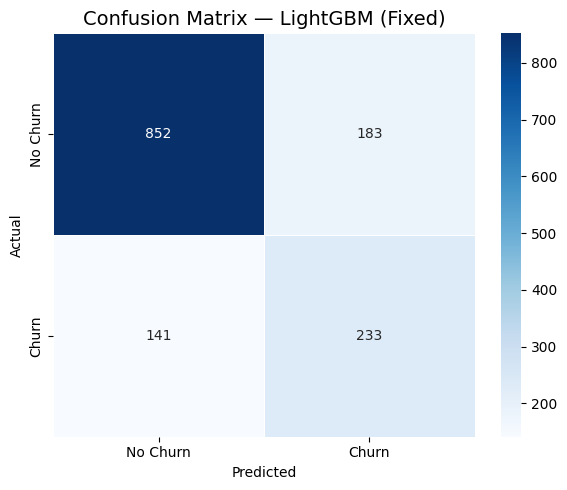

In [64]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            linewidths=0.5, ax=ax)
ax.set_title('Confusion Matrix — LightGBM (Fixed)', fontsize=14)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('plots/07_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [65]:
# ============================================
# STEP 4 — SHAP EXPLAINABILITY
# ============================================
import shap

# Extract trained LightGBM model from pipeline
lgbm_model = pipeline.named_steps['model']

# Get scaled test data from pipeline (aftera smote+scaler steps)
# We need to transform X_test through smote+scaler only (not predict)
from sklearn.pipeline import Pipeline as SKPipeline
preprocessor = SKPipeline([
    ('smote_scale', pipeline.named_steps['scaler'])
])
X_test_transformed = pipeline.named_steps['scaler'].transform(X_test)

# SHAP explainer for tree models
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test_transformed)

print(" SHAP values computed!")
print("Shape:", shap_values.shape if hasattr(shap_values, 'shape') else len(shap_values))

 SHAP values computed!
Shape: (1409, 30)


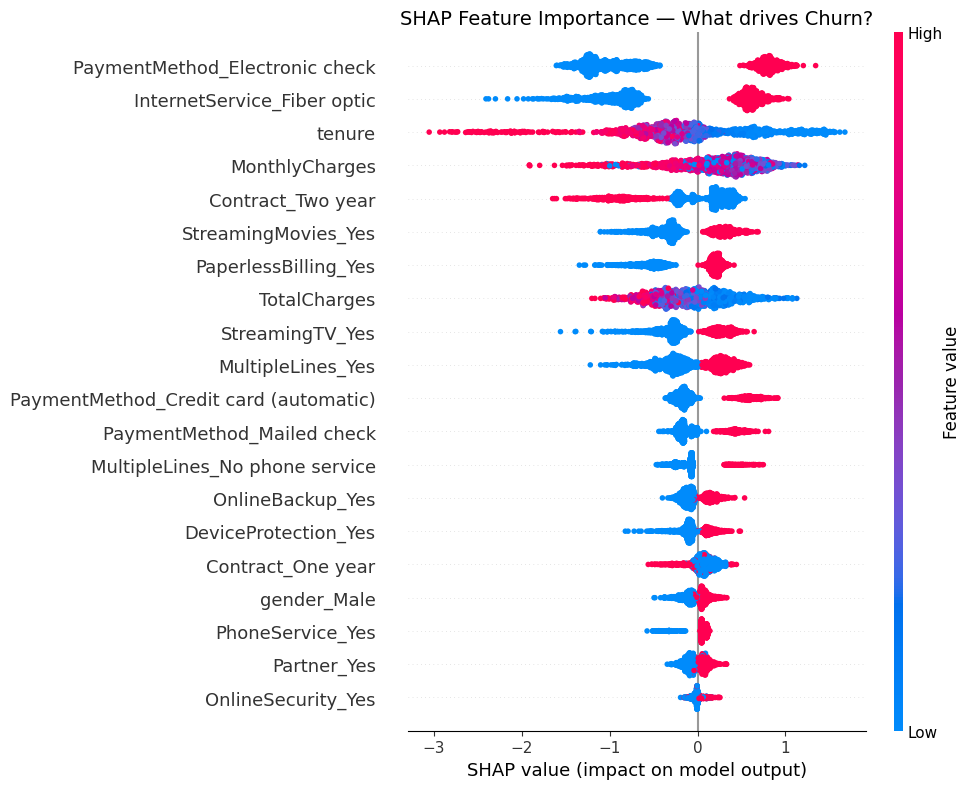

 SHAP summary plot saved!


In [71]:
# --- Plot 1: SHAP Summary Plot (global feature importance) ---
plt.figure(figsize=(10, 8))

# For LightGBM binary classification, shap_values is a list [class0, class1]
# We want class 1 (Churn)
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

shap.summary_plot(sv, X_test_transformed,
                  feature_names=X.columns.tolist(),
                  show=False, plot_size=(10, 8))
plt.title('SHAP Feature Importance — What drives Churn?', fontsize=14)
plt.tight_layout()
plt.savefig('plots/08_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(" SHAP summary plot saved!")

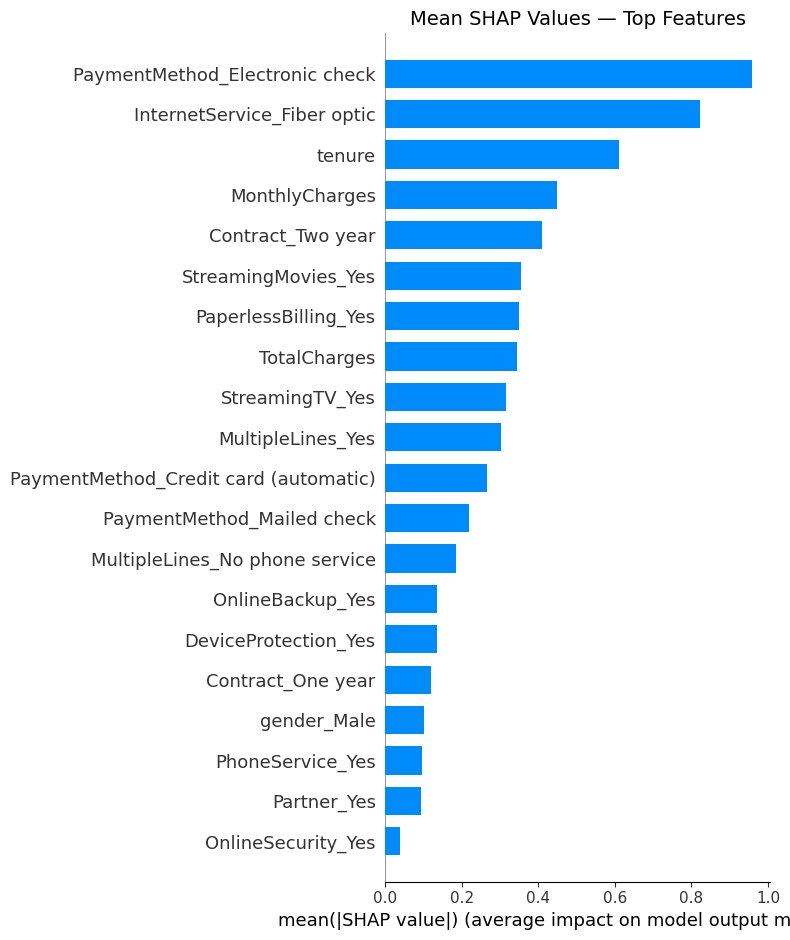

In [72]:
# --- Plot 2: SHAP Bar Plot (mean importance) ---
plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_test_transformed,
                  feature_names=X.columns.tolist(),
                  plot_type='bar', show=False)
plt.title('Mean SHAP Values — Top Features', fontsize=14)
plt.tight_layout()
plt.savefig('plots/09_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

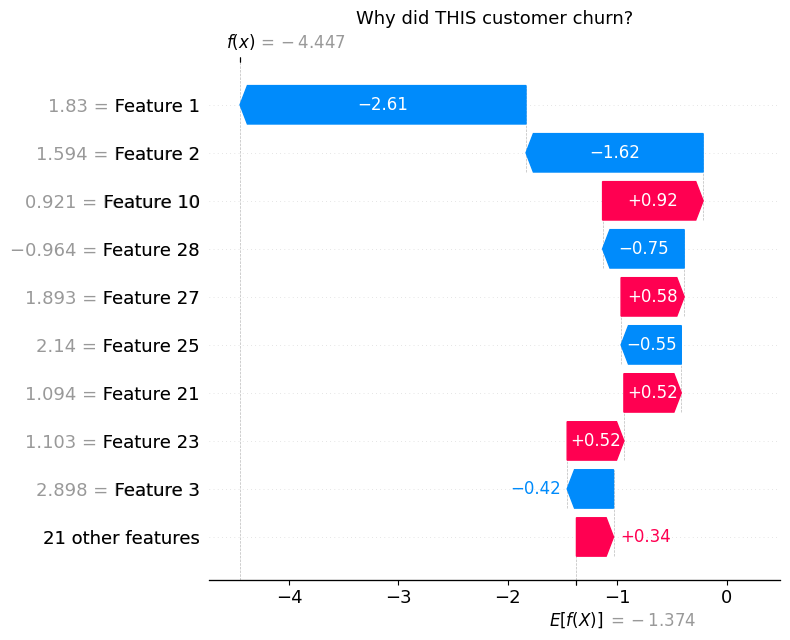

✅ All SHAP plots saved!


In [73]:
# --- Plot 3: Waterfall plot — explain ONE customer prediction ---
# Pick a customer who is predicted to churn
churn_indices = (y_pred == 1)
first_churn_idx = 0  # first predicted churner

explainer2 = shap.Explainer(lgbm_model, X_test_transformed)
shap_values2 = explainer2(X_test_transformed)

shap.plots.waterfall(shap_values2[first_churn_idx], max_display=10, show=False)
plt.title('Why did THIS customer churn?', fontsize=13)
plt.tight_layout()
plt.savefig('plots/10_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ All SHAP plots saved!")

In [74]:

joblib.dump(pipeline, "telco_churn_model.pkl")



['telco_churn_model.pkl']

In [75]:
loaded_model = joblib.load("telco_churn_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [76]:
sample = X_test.iloc[:5]

predictions = loaded_model.predict(sample)

print(predictions)

[0 1 0 0 0]


## Key Findings

- LightGBM achieved the highest ROC-AUC score.
- Contract type strongly influences churn.
- Monthly charges are important churn indicators.
- SHAP analysis confirms feature importance.

## Future Improvements

- Hyperparameter tuning
- Deployment using Streamlit
- Real-time inference API